In [ ]:
%pip install egglog graphviz

### NOTE: Restart after modification

Netlist built in 0.11 seconds
Netlist saturated in 0.05 seconds
(rule ((= wv0 (WireVec_add i (WireVec___init__ ws0) (WireVec___init__ ws1)))
       (FromDffs___init__ ws0 0 ws2)
       (FromDffs___init__ ws1 0 ws3))
      ((ToDffs___init__ wv0 (- i 1) (WireVec_add i (WireVec___init__ ws2) (WireVec___init__ ws3))))
         ): 0 applications
(rule ((= rewrite_var__ (Wire_from_input "1")))
      ((union rewrite_var__ (Wire_from_dff (Wire_from_input "1"))))
         ): 1 applications
(rule ((= rewrite_var__ (Wire_from_input "0")))
      ((union rewrite_var__ (Wire_from_dff (Wire_from_input "0"))))
         ): 1 applications
(rule ((= wv0 (WireVec_mul i (WireVec___init__ ws0) (WireVec___init__ ws1)))
       (FromDffs___init__ ws0 0 ws2)
       (FromDffs___init__ ws1 0 ws3))
      ((ToDffs___init__ wv0 (- i 1) (WireVec_mul i (WireVec___init__ ws2) (WireVec___init__ ws3))))
         ): 1 applications
(rule ((FromDffs___init__ ws0 i ws1)
       (> i 0)
       (= (Wire_from_dff w0) (vec-get ws

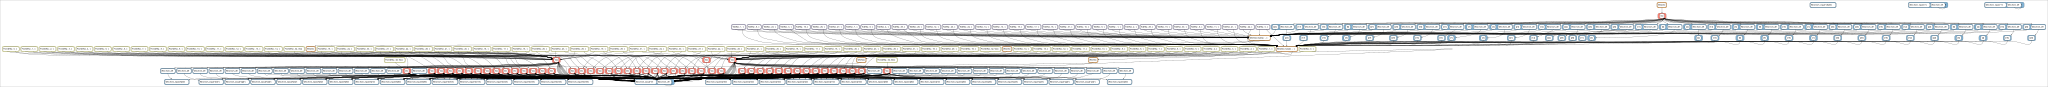

In [2]:
import emap
import json
import time

with open("bad_multiplier.json", "r") as f:
    mod = json.load(f)["modules"]["top"]

netlist = emap.Netlist()

start_time = time.time()
netlist.build_from_json(mod, clk="clk")
print(f"Netlist built in {time.time() - start_time:.2f} seconds")

start_time = time.time()
report = netlist.run((emap.retiming_rules) * 100)
print(f"Netlist saturated in {time.time() - start_time:.2f} seconds")

for rule, count in report.num_matches_per_rule.items():
    print(f"{rule}: {count} applications")

netlist.display(graphviz=True)
# for name, wv in netlist.outputs.items():
#     print(f"{name}: {wv}")